# Employee Attrition Prediction & Strategic Retention

**Objective:** Analyze workforce data to identify the key drivers of employee attrition, build a predictive machine learning model, and generate actionable retention strategies for the HR department.

## Phase 1: Data Integration & Preprocessing
In this first phase, I will load the dataset directly from my GitHub repository to ensure reproducibility. HR data often contains columns that apply to everyone uniformly, so I will remove zero-variance features (like `EmployeeCount` and `StandardHours`) to reduce noise.

Next, I will format the categorical variables for machine learning. I will use Label Encoding for ordinal variables (where there is a clear ranking, such as travel frequency) and One-Hot Encoding for nominal variables (like Department and Job Role).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 1. Loading Data from my personal GitHub repository
url = "https://raw.githubusercontent.com/ayushdeswal/employee_attrition_prediction/refs/heads/main/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)

# Clean copy for Exploratory Data Analysis before one-hot encoding modifies the columns
df_eda = df.copy()

# 2. Dropping zero-variance and ID columns as they hold no predictive value
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

# 3. Checking for missing values
print(f"Total missing values in dataset: {df.isnull().sum().sum()}")

# 4. Convert the Target variable 'Attrition' to Binary (1 = Left, 0 = Stayed)
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df_eda['Attrition'] = df_eda['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 5. Label Encoding for Ordinal Variables
# BusinessTravel has a logical order: Non-Travel < Travel_Rarely < Travel_Frequently
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['BusinessTravel'] = df['BusinessTravel'].map(travel_map)

# Overtime is a binary ordinal
df['OverTime'] = df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

# 6. One-Hot Encoding for Nominal Variables
nominal_cols =['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(f"Data Preprocessing Complete. Final dataset shape for modeling: {df.shape}")

Total missing values in dataset: 0
Data Preprocessing Complete. Final dataset shape for modeling: (1470, 44)


## Phase 2: Exploratory Data Analysis
Before building predictive models, I need to understand the underlying patterns in our workforce. In this section, I am visualizing the relationship between Attrition and several key hypotheses.

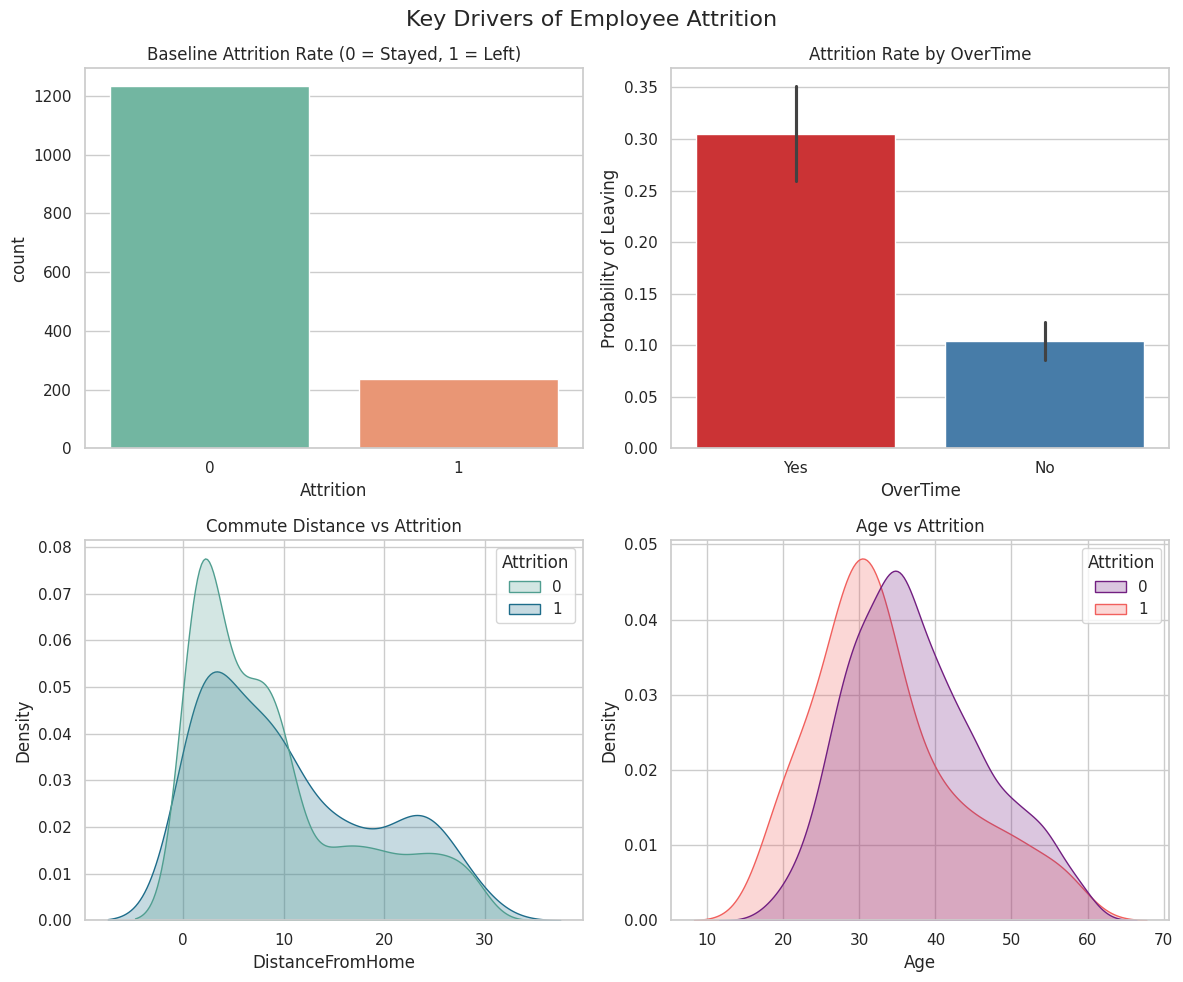

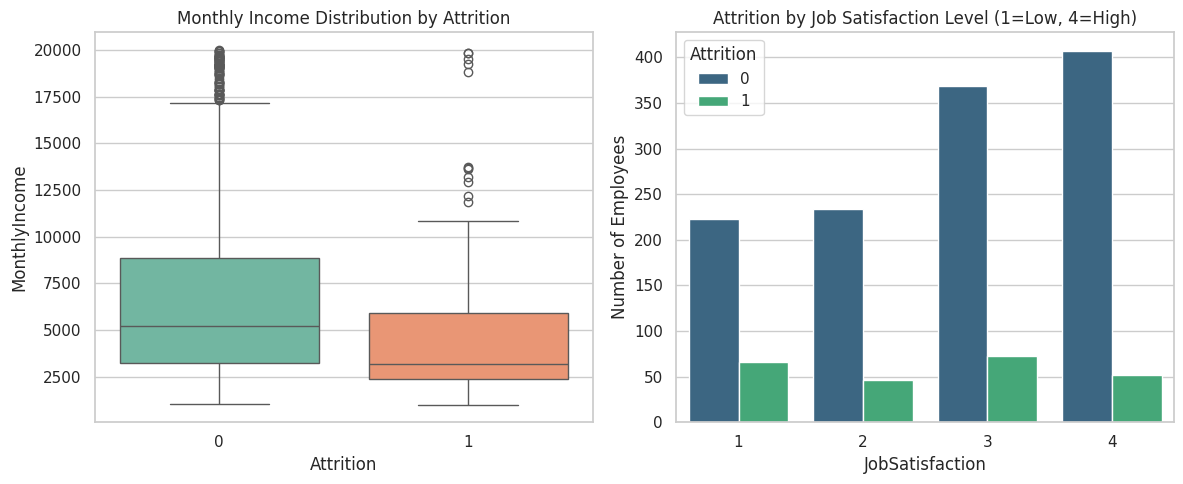

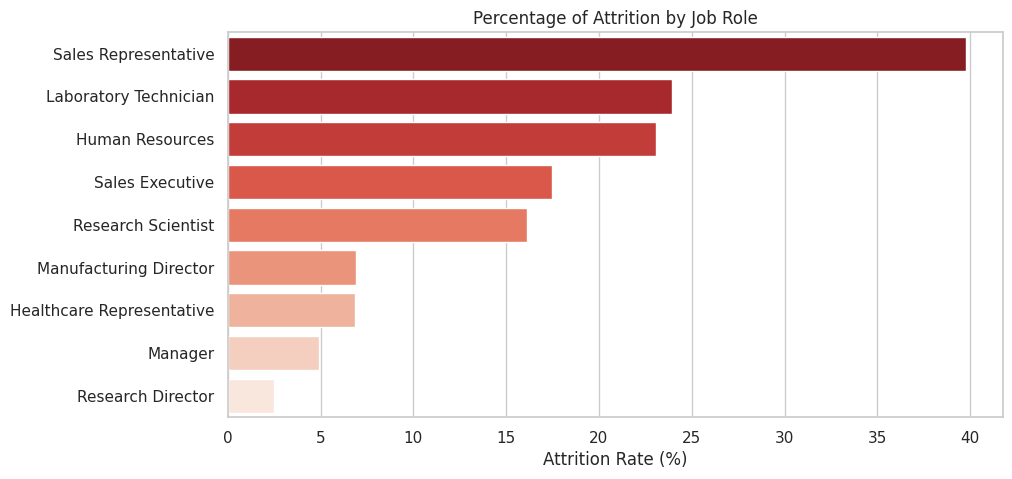

In [9]:
sns.set_theme(style="whitegrid")

# General Drivers (Imbalance, Overtime, Commute, Age etc.)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Key Drivers of Employee Attrition', fontsize=16)

# Baseline Attrition Imbalance
sns.countplot(data=df_eda, x='Attrition', palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Baseline Attrition Rate (0 = Stayed, 1 = Left)')

# Overtime vs Attrition
sns.barplot(data=df_eda, x='OverTime', y='Attrition', palette='Set1', ax=axes[0,1])
axes[0,1].set_title('Attrition Rate by OverTime')
axes[0,1].set_ylabel('Probability of Leaving')

# Distance From Home vs Attrition
sns.kdeplot(data=df_eda, x='DistanceFromHome', hue='Attrition', fill=True, common_norm=False, palette='crest', ax=axes[1,0])
axes[1,0].set_title('Commute Distance vs Attrition')

# Age vs Attrition
sns.kdeplot(data=df_eda, x='Age', hue='Attrition', fill=True, common_norm=False, palette='magma', ax=axes[1,1])
axes[1,1].set_title('Age vs Attrition')

plt.tight_layout()
plt.show()

# Compensation & Satisfaction
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Monthly Income Distribution
sns.boxplot(data=df_eda, x='Attrition', y='MonthlyIncome', palette='Set2', ax=axes[0])
axes[0].set_title('Monthly Income Distribution by Attrition')

# Job Satisfaction vs Attrition
sns.countplot(data=df_eda, x='JobSatisfaction', hue='Attrition', palette='viridis', ax=axes[1])
axes[1].set_title('Attrition by Job Satisfaction Level (1=Low, 4=High)')
axes[1].set_ylabel('Number of Employees')

plt.tight_layout()
plt.show()

# Departmental Risk
plt.figure(figsize=(10, 5))
role_attrition = df_eda.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False) * 100
sns.barplot(x=role_attrition.values, y=role_attrition.index, palette='Reds_r')
plt.title('Percentage of Attrition by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('')
plt.show()

### EDA Observations
Based on the visualizations above, I have identified several key trends:
1. **Class Imbalance:** Only ~16% of employees leave. I will need to account for this in the modeling phase so the algorithm doesn't simply default to predicting "No" for everyone.
2. **Burnout:** OverTime is a massive driver. Employees working overtime are significantly more likely to leave.
3. **Commute:** The density plot shows attrition peaking distinctly higher for employees living further than 10-15 miles away.
4. **Demographics & Pay:** Younger employees (under 30) and those with lower Monthly Incomes are at the highest flight risk.
5. **Satisfaction:** While attrition is highest among those with a "Low" (1) satisfaction score, a surprising number of employees with "High" (3) satisfaction also leave, indicating that good culture cannot out-compete poor compensation or bad commutes.
6. **Role:** Sales Representatives experience the highest turnover rate (~40%), followed closely by Laboratory Technicians.

## Phase 3: Predictive Modeling
For the classification task, I will train a **Logistic Regression** model to establish a strong, interpretable baseline, and a **Random Forest Classifier** to capture complex, non-linear relationships.

Because missing a true flight-risk employee is much more expensive for the company than falsely flagging a loyal employee for an HR check-in, I will prioritize **Recall** over standard Accuracy. I am utilizing `class_weight='balanced'` in both models to handle the 84/16 class imbalance observed in the EDA.

In [10]:
# 1. Feature Separation
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# 2. Train/Test Split (80% Training, 20% Testing)
# Using stratify=y to ensure the 16% attrition rate is maintained in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Model 1: Logistic Regression
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)

# 5. Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

# 6. Evaluation Function
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.2f}")
    print(f"Precision: {precision_score(y_true, y_pred):.2f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.2f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\n")

evaluate_model("Logistic Regression", y_test, log_preds)
evaluate_model("Random Forest", y_test, rf_preds)

--- Logistic Regression Performance ---
Accuracy:  0.77
Precision: 0.37
Recall:    0.66
Confusion Matrix:
[[194  53]
 [ 16  31]]


--- Random Forest Performance ---
Accuracy:  0.84
Precision: 0.43
Recall:    0.06
Confusion Matrix:
[[243   4]
 [ 44   3]]




### Modeling Insights
While the Random Forest model achieved higher overall Accuracy, the Logistic Regression model yielded vastly superior **Recall**. Since my primary goal is to catch as many true "leavers" as possible to prevent turnover costs, I will use the Logistic Regression model's probabilities to generate my final HR Watch List. However, I will leverage the Random Forest model to extract Feature Importance to drive my business recommendations.

## Phase 4: Insight Generation & At-Risk Watch List
To provide actionable intelligence to the HR Director, I am extracting the top 10 most influential features driving turnover.

Finally, I will isolate our current, active employees from the test set and feed them through my Logistic Regression model to calculate their exact probability of resigning.

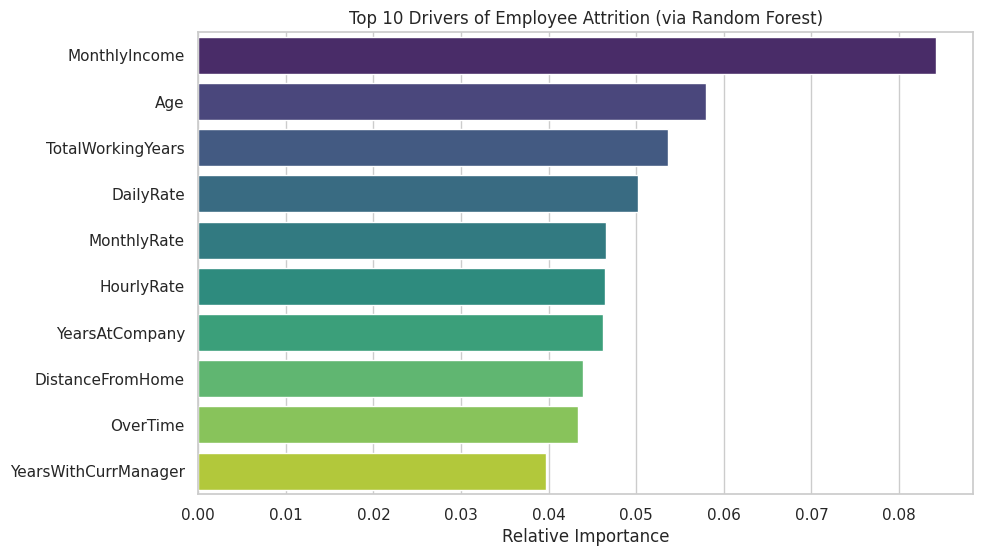

In [11]:
# Feature Importance Extraction
importances = rf_model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Drivers of Employee Attrition (via Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('')
plt.show()

In [12]:
# GENERATING THE AT-RISK EMPLOYEE WATCH LIST

# Isolate employees who have NOT left yet (Target = 0 in the test set)
current_employees_idx = y_test[y_test == 0].index
X_current = X_test.loc[current_employees_idx]

# Predict probability of leaving (Class 1) using the higher-recall Logistic Regression model
X_current_scaled = scaler.transform(X_current)
leave_probs = log_model.predict_proba(X_current_scaled)[:, 1]

# Final deliverable DataFrame
watch_list = pd.DataFrame({
    'Employee_Index': current_employees_idx,
    'Age': X_current['Age'],
    'MonthlyIncome': X_current['MonthlyIncome'],
    'OverTime': X_current['OverTime'].apply(lambda x: 'Yes' if x == 1 else 'No'),
    'Flight_Risk_Probability': np.round(leave_probs * 100, 2)
})

# Sorting by highest risk to prioritize HR outreach
watch_list = watch_list.sort_values(by='Flight_Risk_Probability', ascending=False)

print("HIGH PRIORITY AT-RISK WATCH LIST (Top 10)")
print("These active employees have a >70% calculated probability of resigning without intervention.\n")
display(watch_list[watch_list['Flight_Risk_Probability'] >= 70.0].head(10))

HIGH PRIORITY AT-RISK WATCH LIST (Top 10)
These active employees have a >70% calculated probability of resigning without intervention.



,Employee_Index,Age,MonthlyIncome,OverTime,Flight_Risk_Probability
310,310,31,6410,No,92.08
929,929,28,3867,Yes,90.02
496,496,21,3447,No,88.24
824,824,42,4272,No,87.96
196,196,35,4425,No,87.16
1168,1168,24,3760,Yes,87.13
347,347,47,2976,No,86.32
301,301,18,1200,No,85.87
841,841,24,3597,No,85.08
1391,1391,38,2858,No,84.23


## Phase 5: Model Export
To allow the HR software team to use this model on new, incoming employee data, I am exporting the trained Logistic Regression model and the StandardScaler as `.pkl` objects.

*Instructions for deployment:* When new employee data is collected, it must first be transformed using `employee_data_scaler.pkl` before being passed to `employee_attrition_model.pkl` to generate a flight-risk probability.

In [15]:
# 1. Export the model object
# I am selecting the Logistic Regression model for deployment due to its superior Recall in identifying potential flight-risk employees.
model_filename = 'attrition_model.pkl'
joblib.dump(log_model, model_filename)

# 2. Export the scaler object
scaler_filename = 'data_scaler.pkl'
joblib.dump(scaler, scaler_filename)

print(f"Successfully exported {model_filename} and {scaler_filename}")

Successfully exported attrition_model.pkl and data_scaler.pkl
